# This was used for Qz#3 F2025

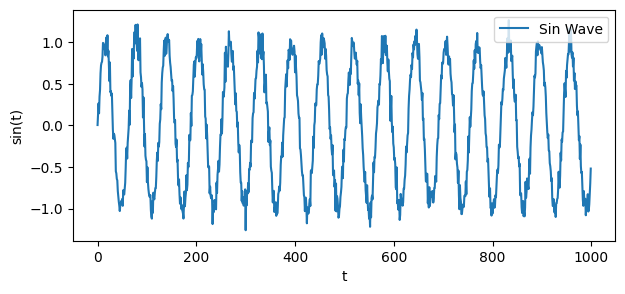

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# Generate synthetic univariate time series data (sine wave) and add slight noise
time = np.arange(0, 100, 0.1) # 1,000
data = np.sin(time) + 0.1 * np.random.randn(len(time)) # 1K random#s from N(0,1) distribution

plt.figure(figsize=(7, 3))
plt.plot(data, label='Sin Wave')
plt.xlabel('t')
plt.ylabel('sin(t)')
plt.legend()
plt.show()

In [2]:
def create_dataset(series, look_back_ts):  # Prepare supervised learning dataset
    X, y = [], []
    for i in range(len(series) - look_back_ts):
        X.append(series[i : i+look_back_ts])
        y.append(series[i+look_back_ts])
    return np.array(X), np.array(y)

# Define Objective fn with 3 variables (3 Hyperparams)
# 0: NUM_NEURONS     1: LOOK_BACK_TS      2: BATCH_SIZE
def objective_fn(hparams):
    global y_test, pred  # to plot
    NUM_NEURONS = round(hparams[0])
    LOOK_BACK_TS = round(hparams[1])
    BATCH_SIZE = round(hparams[2])

    X, y = create_dataset(data, LOOK_BACK_TS)
    # Reshape input to (samples, timesteps, features) for LSTM / GRU
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Split into train (80%) and test (20%) sets
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    model = Sequential([
        keras.Input(shape=(LOOK_BACK_TS, 1)),
        LSTM(NUM_NEURONS),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=BATCH_SIZE, validation_split=0.2, verbose=0)
    pred = model.predict(X_test, verbose=0)

    # Calculate Root Mean Square Error (RMSE)
    mse = np.mean((pred - y_test) ** 2)
    rmse = np.sqrt(mse)
    return rmse

In [3]:
def print_HP_found(x, eval):
  print(f"NUM_NEURONS={int(x[0])}, LOOK_BACK_TS={int(x[1])}, BATCH_SIZE={int(x[2])}")
  print(f"RMSE={eval}")

In [4]:
def es1115(objfunc, hparams, numVar, MaxGen, WindowSize,
           stepSize_i=0.82, stepSize_r=0.82):

    xp = np.empty(numVar) # parent
    xo = np.empty(numVar) # offspring
    p_val, o_val, successCnt = 0, 0, 0

    for i in range(numVar):  # Assign initial values to parent.
        xp[i] = hparams[i][0]

    p_val = objfunc(xp)     # evaluate the parent
    stepSize = stepSize_i

    for g in range(1, MaxGen+1):
        if (g % WindowSize) == 0: # update stepsize
            if successCnt > (WindowSize * 0.2):
                stepSize = stepSize / stepSize_r #increase
            elif successCnt < (WindowSize * 0.2):
                stepSize = stepSize * stepSize_r #decrease
            successCnt = 0

        for i in range(numVar): # mutate each hyperparameter
            stepSize_scaled = stepSize*(hparams[i][2]-hparams[i][1])
            xo[i] = xp[i] + round(np.random.normal(0.0, stepSize_scaled))
            # to correct if any variation goes out of acceptable range
            # hparams[i][1]: lower_bound. clip - lower upper both inclusive
            xo[i] = np.clip(xo[i], hparams[i][1], hparams[i][2])

        o_val = objfunc(xo)  # evaluate offspring
        if o_val < p_val: # select
            xp = xo.copy()
            p_val = o_val
            successCnt += 1

        if p_val < 0.9: # RMSE should be small...
            return xp, p_val, g, True

    return xp, p_val, MaxGen, False


************************** Trial # = 1


NUM_NEURONS=58, LOOK_BACK_TS=6, BATCH_SIZE=15
RMSE=0.9494506114924565


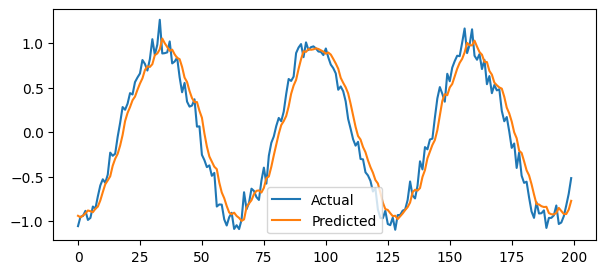


************************** Trial # = 2
NUM_NEURONS=100, LOOK_BACK_TS=18, BATCH_SIZE=8
RMSE=0.9673932863688682


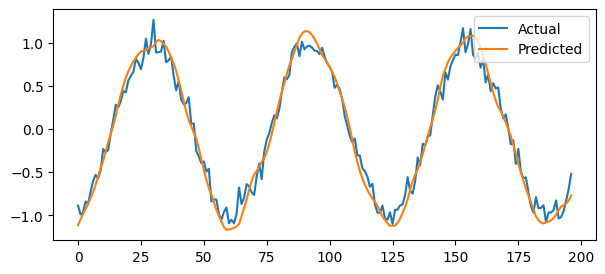

In [5]:
# Constants needed for ES Optimization
MaxGen = 30
numVar = 3 # Number of Hyperparams
WindowSize = 10
best_p_val = 99999 # a large number

############ M A I N ###################
for trial in range(0, 2): # MaxTrial is 2
    # initialize hyperParams in tuples (initial_value, lower_bound, upper_bound)
    hparams = [
        (50, 30, 100),   # 0. num neurons
        (4, 3, 18),      # 1. look_back_ts
        (16, 8, 32),     # 2. num batch size
    ]
    print(f"\n************************** Trial # = {trial+1}")
    xp, p_val, generations, success = es1115(objective_fn, hparams, numVar, MaxGen, WindowSize)

    if success:
        print(f"Acceptable solution found after {generations} generations:")
        if p_val < best_p_val:
            best_p_val = p_val
            print(f"best_p_val = {best_p_val}")
    print_HP_found(xp, p_val)
    plt.figure(figsize=(7, 3))
    plt.plot(y_test, label='Actual')
    plt.plot(pred, label='Predicted')
    plt.legend()
    plt.show()